# Import all libraries

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score,classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, roc_curve

# Regression Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Load Dataset

In [17]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


# Implement Bagging Classifier for Course Completion Prediction

## Features & Target

In [18]:
X = df.drop(["completion_status", "final_score"], axis=1)

y = df["completion_status"]

## Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Decision Tree Classifier

In [20]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

base_acc = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy :", base_acc * 100)

Decision Tree Accuracy : 62.88461538461539


In [28]:
dt_accuracy = accuracy_score(y_test,y_pred_dt)
dt_precision = precision_score(y_test,y_pred_dt)
dt_recall = recall_score(y_test,y_pred_dt)
dt_f1 = f1_score(y_test,y_pred_dt)
dt_auc = roc_auc_score(y_test,dt_prob)

print("Decision Tree")

print("Accuracy :",dt_accuracy)
print("Precision :",dt_precision)
print("Recall :",dt_recall)
print("F1 :",dt_f1)
print("ROC AUC :",dt_auc)

Decision Tree
Accuracy : 0.6288461538461538
Precision : 0.508235294117647
Recall : 0.549618320610687
F1 : 0.5281173594132029
ROC AUC : 0.6132944771523297


## Bagging Classifier

In [21]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [22]:
y_pred = bag_clf.predict(X_test)
bag_prob = bag_clf.predict_proba(X_test)[:,1]

## Bagging Evaluation

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
bag_auc = roc_auc_score(y_test,bag_prob)
print("Bagging")
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :",bag_auc)

Bagging
Accuracy : 0.6951923076923077
Precision : 0.6210191082802548
Recall : 0.4961832061068702
F1 Score : 0.5516265912305516
ROC AUC : 0.7457338823538667


## Classification report

In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77       647
         1.0       0.62      0.50      0.55       393

    accuracy                           0.70      1040
   macro avg       0.67      0.66      0.66      1040
weighted avg       0.69      0.70      0.69      1040



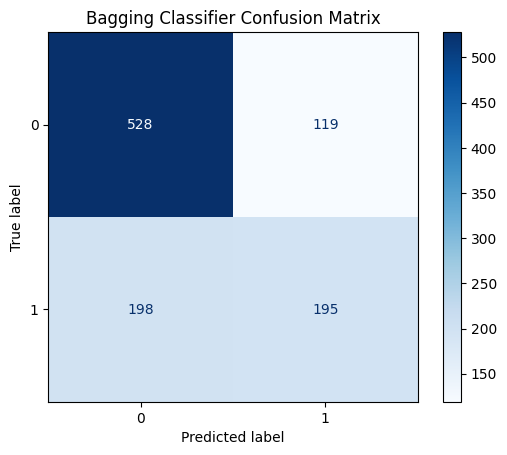

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Bagging Classifier Confusion Matrix")
plt.show()

## ROC Curve Comparison

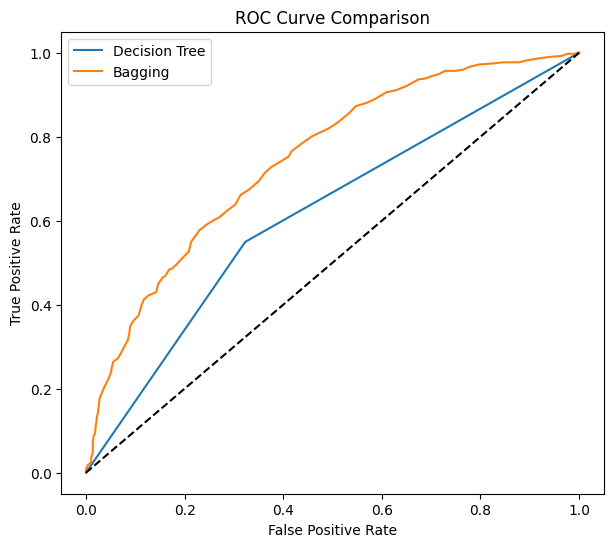

In [26]:
dt_fpr,dt_tpr,_ = roc_curve(y_test,dt_prob)

bag_fpr,bag_tpr,_ = roc_curve(y_test,bag_prob)

plt.figure(figsize=(7,6))

plt.plot(dt_fpr,dt_tpr,label="Decision Tree")

plt.plot(bag_fpr,bag_tpr,label="Bagging")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Classification Comparison

In [31]:
classification_results = pd.DataFrame({

    "Model":["Decision Tree","Bagging"],
    "Accuracy":[dt_accuracy,accuracy],
    "Precision":[dt_precision,precision],
    "Recall":[dt_recall,recall],
    "F1 Score":[dt_f1,f1],
    "ROC AUC":[dt_auc,bag_auc]

})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.628846,0.508235,0.549618,0.528117,0.613294
1,Bagging,0.695192,0.621019,0.496183,0.551627,0.745734


# Implement Bagging Regressor for Final Score Prediction

## Features & Target

In [32]:
X = df.drop(["completion_status", "final_score"], axis=1)

y = df["final_score"]

## Train Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Decision Tree Regressor

In [ ]:
dt_reg = DecisionTreeRegressor(random_state=42)

dt_reg.fit(X_train,y_train)

y_pred_dt = dt_reg.predict(X_test)

Decision Tree R2 Score : -3.0932667216690746


## Evaluation

In [35]:
dt_mae = mean_absolute_error(y_test,y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test,y_pred_dt))
dt_r2 = r2_score(y_test,y_pred_dt)

print("Decision Tree")

print("MAE :",dt_mae)
print("RMSE :",dt_rmse)
print("R2 :",dt_r2)

Decision Tree
MAE : 10.985096153846154
RMSE : 13.878725071683805
R2 : -0.030932667216690746


## Bagging Regressor

In [36]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [37]:
y_pred = bag_reg.predict(X_test)

## Evaluation

In [38]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 8.039950000000001
MSE : 100.50218380961539
RMSE : 10.025077745814015
R2 Score : 0.4620936706982558


## Actual vs Predicted Plot

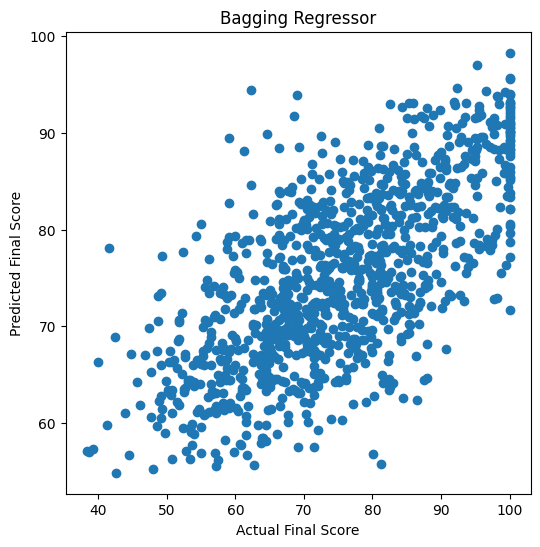

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Bagging Regressor")
plt.show()

## Regression Comparison

In [46]:
regression_results = pd.DataFrame({

    "Model":["Decision Tree","Bagging"],

    "MAE":[dt_mae,mae],

    "RMSE":[dt_rmse,rmse],

    "R2 Score":[dt_r2,r2]

})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,10.985096,13.878725,-0.030933
1,Bagging,8.039950,10.025078,0.462094


In [47]:
print("Best Classification Model")

print(classification_results.sort_values(
    by="Accuracy",
    ascending=False
))

print()

print("Best Regression Model")

print(regression_results.sort_values(
    by="R2 Score",
    ascending=False
))

Best Classification Model
           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
1        Bagging  0.695192   0.621019  0.496183  0.551627  0.745734
0  Decision Tree  0.628846   0.508235  0.549618  0.528117  0.613294

Best Regression Model
           Model        MAE       RMSE  R2 Score
1        Bagging   8.039950  10.025078  0.462094
0  Decision Tree  10.985096  13.878725 -0.030933


# Conclusion 
## Bagging Classifier
* Successfully predicted student course completion.
* Achieved good Accuracy, Precision, Recall, and F1-Score.
* Reduced overfitting by combining multiple Decision Trees.
## Bagging Regressor
* Predicted students' final scores effectively.
* Evaluated using MAE, MSE, RMSE, and R² Score.
* Provided more stable predictions than a single Decision Tree

# Classification:
Bagging Classifier generally performs better than the single Decision Tree by improving Accuracy, Precision, Recall, F1-Score, and ROC-AUC through ensemble learning, making it more robust and less prone to overfitting.

# Regression:
Bagging Regressor usually achieves a lower RMSE and higher R² score than the single Decision Tree Regressor, indicating better prediction accuracy for students' final scores.